# Tensor de inercia del monóxido de carbono

[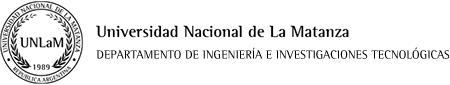](https://ingenieria.unlam.edu.ar/)  
[by-nc-sa_80x15.png](https://creativecommons.org/licenses/by-sa/4.0/deed.es_ES) 
2026 [Víctor A. Bettachini](mailto:vbettachini@unlam.edu.ar)  

---

In [1]:
# biblioteca de cálculo simbólico
import sympy as sm
import sympy.physics.mechanics as me
me.init_vprinting() # notación con puntos para derivadas temporales

In [2]:
O_m, C_m, d = sm.symbols('m_O, m_C, d', positive=True) # tilde para diferenciar densidad de radio

Hay dos átomos en este sistema. 
Por conveniencia, partimos de tomar un sistema de referencia cartesiano, con origen en el átomo de oxígeno (O) y a una distancia $d$ en el eje $x$ del átomo de carbono (C).

In [3]:
# Sistema cartesiano
e = sm.physics.vector.ReferenceFrame('e') # marco referencial e en coordenadas cartesianas

# posiciones
O_r = 0* (e.x + e.y + e.z) # origen
C_r = d* (e.x)

## Tensor de inercia para masas discretas 

Solo se contemplarán los núcleos en los extremos de los enlaces considerados como masas puntuales.
Por tanto se utiliza la expresión del tensor de inercia para distribuciones discretas de masa.

$$
\overline{\overline{I}}
= I_{ik} = 
\begin{pmatrix}
I_{xx} & I_{xy} & I_{xz} \\
I_{yx} & I_{yy} & I_{yz} \\
I_{zx} & I_{zy} & I_{zz} \\
\end{pmatrix}
=
\begin{pmatrix}
\sum_p m_p (y_p^2 + z_p^2) & - \sum_p m_p x_p y_p & - \sum_p m_p x_p z_p \\
- \sum_p m_p y_p x_p & \sum_p m_p (x_p^2 + z_p^2)  & - \sum_p m_p y_p z_p \\
- \sum_p m_p z_p x_p & - \sum_p m_p z_p y_p & \sum_p m_p (x_p^2 + y_p^2) \\
\end{pmatrix}
$$

Los momentos de inercia, en la diagonal del tensor.

In [4]:
Ixx = (
       O_m* (O_r.dot(e.y)**2 + O_r.dot(e.z)**2) +
       C_m* (C_r.dot(e.y)**2 + C_r.dot(e.z)**2)
      ).simplify()
Iyy = (
       O_m* (O_r.dot(e.x)**2 + O_r.dot(e.z)**2) +
       C_m* (C_r.dot(e.x)**2 + C_r.dot(e.z)**2)
      ).simplify()
Izz = (
       O_m* (O_r.dot(e.x)**2 + O_r.dot(e.y)**2) +
       C_m* (C_r.dot(e.x)**2 + C_r.dot(e.y)**2)
      ).simplify()

En esta geometría los productos de inercia, son nulos, pero se los calcula para verificar esto.

In [5]:
Ixy = - (
      O_m* (O_r.dot(e.x)* O_r.dot(e.y) ) +
      C_m* (C_r.dot(e.x)* C_r.dot(e.y) )
      ).simplify()
Iyx = Ixy
Ixz = - (
      O_m* (O_r.dot(e.x)* O_r.dot(e.z) ) +
      C_m* (C_r.dot(e.x)* C_r.dot(e.z) )
      ).simplify()
Izx = Ixz
Iyz = - (
      O_m* (O_r.dot(e.y)* O_r.dot(e.z) ) +
      C_m* (C_r.dot(e.y)* C_r.dot(e.z) )
      ).simplify()
Izy = Iyz

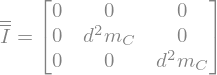

In [6]:
I_ik = sm.Eq(
  sm.Symbol(r'\overline{\overline{I}}'),
  sm.Matrix(
    [
      [Ixx, Ixy, Ixz],
      [Ixy, Iyy, Iyz],
      [Izx, Izy, Izz]
    ]
  ),
  evaluate=False
)
I_ik

## Tensor de inercia para rotaciones desde el centro de masa con teorema de Steiner

Se pide calcular los momentos de inercia.
Estos, como sabemos, son los elementos de la diagonal en el tensor de inercia si los ejes en que se calcula este último están alineados con los de simetría de la molécula y parten desde su centro de masa.

En la sección anterior calculamos un tensor de inercia con un sistema de referencia con un origen arbitrario, la posición del átomo de oxígeno.
Así que corresponde aplicar el teorema de Steiner para trasladar el tensor de inercia al centro de masa del sistema.

Si se calcula con un sistema de ejes $x'_i$ que no parten del centro de masa, se puede calcular un tensor $I'_{ik}$ con el que luego se puede recuperar el calculado desde el centro de masa $I_{ik}$

$$
I_{ik} = I'_{ik} - M [ a^2 \delta_{ik} - a_i a_k ]
$$
donde $M$ es la masa de todo el sistema y $\vec{a}$ va del origen de este sistema al centro de masa.

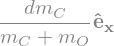

In [7]:
masa = O_m + C_m
cm_r = (C_m* C_r)/ masa
cm_r

Con este dato hay que calcular el término de Steiner

$$
M [ a^2 \delta_{ik} - a_i a_k ]
=
\begin{pmatrix}
M (a_y^2 + a_z^2) & - M a_x a_y & - M a_x a_z \\
- M a_y a_x & M (a_x^2 + a_z^2) & - M a_y a_z \\
- M a_z a_x & - M a_z a_y & M (a_x^2 + a_y^2),
\end{pmatrix}
$$

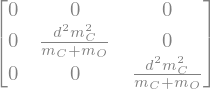

In [8]:
a_x = cm_r.dot(e.x)
a_z = cm_r.dot(e.z)
a_y = cm_r.dot(e.y)
steiner_M = masa* sm.Matrix(
  [
    [(a_y**2 + a_z**2) , - a_x* a_y, - a_x* a_z],
    [- a_y* a_x, (a_x**2 + a_z**2), - a_y* a_z],
    [- a_z* a_x, - a_z* a_y, (a_x**2 + a_y**2)]
  ]
  )
steiner_M

Con lo que puede obtenerse el tensor de inercia calculado desde el centro de masa.

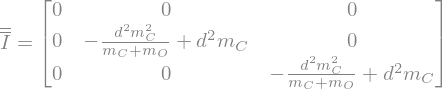

In [9]:
Iik_cm = sm.Eq(
  I_ik.lhs,
  I_ik.rhs - steiner_M,
  evaluate=False
) 
Iik_cm

Siempre es conveniente simplificar cada elemento del tensor.

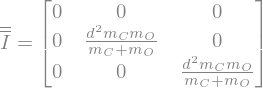

In [10]:
Iik_cm = sm.Eq(
  Iik_cm.lhs,
  Iik_cm.rhs.applyfunc(sm.simplify),
  evaluate=False
)
Iik_cm

Se substituyen las magnitudes para obtener los momentos de inercia en unidades de $\mathrm{kg\,m^2}$.

In [11]:
# geometría CO
# https://cccbdb.nist.gov/exp2x.asp
d_magnitud = 1.1282 # [angstrom]
d_magnitud *= 1E-10 # [m]

# masas
# https://iupac.org/wp-content/uploads/2022/05/IUPAC_Periodic_Table_150-04May22.jpg
constanteAvogadro = 6.02214076E23 # [mol^-1]
O_m_magnitud = 15.999 # [u]
O_m_magnitud *= 1E-3/ constanteAvogadro # [kg]
C_m_magnitud = 12.011 # [u]
C_m_magnitud *= 1E-3/ constanteAvogadro # [kg]

parametros = {
    O_m : O_m_magnitud,
    C_m : C_m_magnitud,
    d : d_magnitud,
}

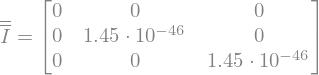

In [12]:
Iik_cm = sm.Eq(
  Iik_cm.lhs,
  Iik_cm.rhs.subs(parametros).evalf(n=3),
  evaluate=False
) # tres cifras significativas
Iik_cm

In [13]:
from sympy.physics.vector import vlatex

In [14]:
print(
  vlatex(
    Iik_cm
    )
  )

\overline{\overline{I}} = \left[\begin{matrix}0 & 0 & 0\\0 & 1.45 \cdot 10^{-46} & 0\\0 & 0 & 1.45 \cdot 10^{-46}\end{matrix}\right]


## Rotación del tensor de inercia

Para esto se diagonaliza el tensor de inercia calculando sus vectores propios (autovectores), $\vec{v}_i$ y generando con estos la matriz de rotación, Q como
$$
Q =
\begin{bmatrix}
| & | & | \\
\vec{v}_{1} & \vec{v}_{2} & \vec{v}_{3} \\
| & | & |
\end{bmatrix}
.
$$

El tensor rotado se obtiene como
$$
\overline{\overline{\Lambda}} = Q^{-1} \overline{\overline{I}} Q
,
$$
donde $\Lambda$ es una matriz diagonal con los autovalores del tensor de inercia original, $\overline{\overline{I}}$.


Es habitual alinear el sistema de ejes para que el mayor momento de inercia sea el momento de inercia principal $I_{zz}$, y luego $I_{yy}$.
Esto hace que sin importar que orientación de eje se eligió para el sistema de referencia, el tensor de inercia rotado será el mismo.

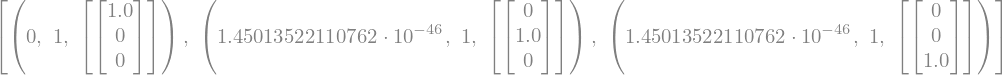

In [15]:
autovectores = Iik_cm.rhs.eigenvects()
autovectores # en cada uno: autovalor, multiplicidad, autovector

En Q se ordenan los vectores propios de acuerdo al menor valor propio respectivo $\lambda_i$ a los fines de que el mayor momento de inercia figure en la última fila y columna, es decir,sea $I_{zz}$.


En este caso no habría que hacer nada, pero se aplicará el código que efectuá esto para aplicarle cuando sea necesario.

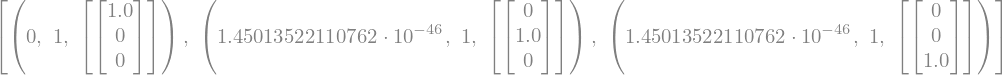

In [16]:
autovectores = sorted(autovectores, key=lambda x: x[0]) # ordena de menor a mayor autovalor
autovectores

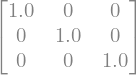

In [17]:
Q = sm.Matrix.hstack(*[autovectores[i][2][0] for i in range(3)]) # autovectores como columnas
Q

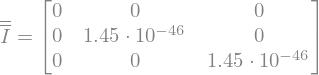

In [18]:
lambda_tensor = sm.Eq(
  Iik_cm.lhs,
  (Q.inv()* Iik_cm.rhs* Q).evalf(n=3),
  evaluate=False
)
lambda_tensor

In [19]:
print(
  vlatex(
    lambda_tensor
    )
  )

\overline{\overline{I}} = \left[\begin{matrix}0 & 0 & 0\\0 & 1.45 \cdot 10^{-46} & 0\\0 & 0 & 1.45 \cdot 10^{-46}\end{matrix}\right]


### Un método más directo para diagonalizar el tensor de inercia

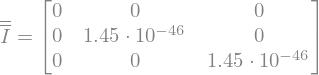

In [27]:
P, D = Iik_cm.rhs.diagonalize()
lambda_tensor = sm.Eq(
  Iik_cm.lhs,
  D.evalf(n=3),
  evaluate=False
)
lambda_tensor